In [1]:
import pandas as pd
import numpy as np

%matplotlib inline
# matplotlib.use('TkAgg')  # or 'QtAgg', etc.

import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science', 'ieee'])

# Increase fonts globally (adjust sizes as needed)
# DEFAULT IS 12
plt.rcParams.update({
    'font.size': 15,            # default text size
    'axes.titlesize': 15,      # axes title
    'axes.labelsize': 15,      # x/y labels
    'xtick.labelsize': 15,     # x tick labels
    'ytick.labelsize': 15,     # y tick labels
    'legend.fontsize': 15,     # legend text
    'figure.titlesize': 15
})

In [2]:
# Import data
df_vo = pd.read_csv('data/log_19_2025-10-21-21-16-02_vehicle_odometry_0.csv')
df_vvo = pd.read_csv('data/log_19_2025-10-21-21-16-02_vehicle_visual_odometry_0.csv')

In [3]:
t_vvo = (df_vvo['timestamp'].to_numpy() - df_vvo['timestamp'].to_numpy()[0]) / 1e6
t_vo = (df_vo['timestamp'].to_numpy() - df_vo['timestamp'].to_numpy()[0]) / 1e6
pos1_vvo = df_vvo['position[0]'].to_numpy()
pos1_vo = df_vo['position[0]'].to_numpy()
pos3_vvo = -df_vvo['position[1]'].to_numpy()
pos3_vo = -df_vo['position[1]'].to_numpy()
pos2_vvo = df_vvo['position[2]'].to_numpy()
pos2_vo = df_vo['position[2]'].to_numpy()

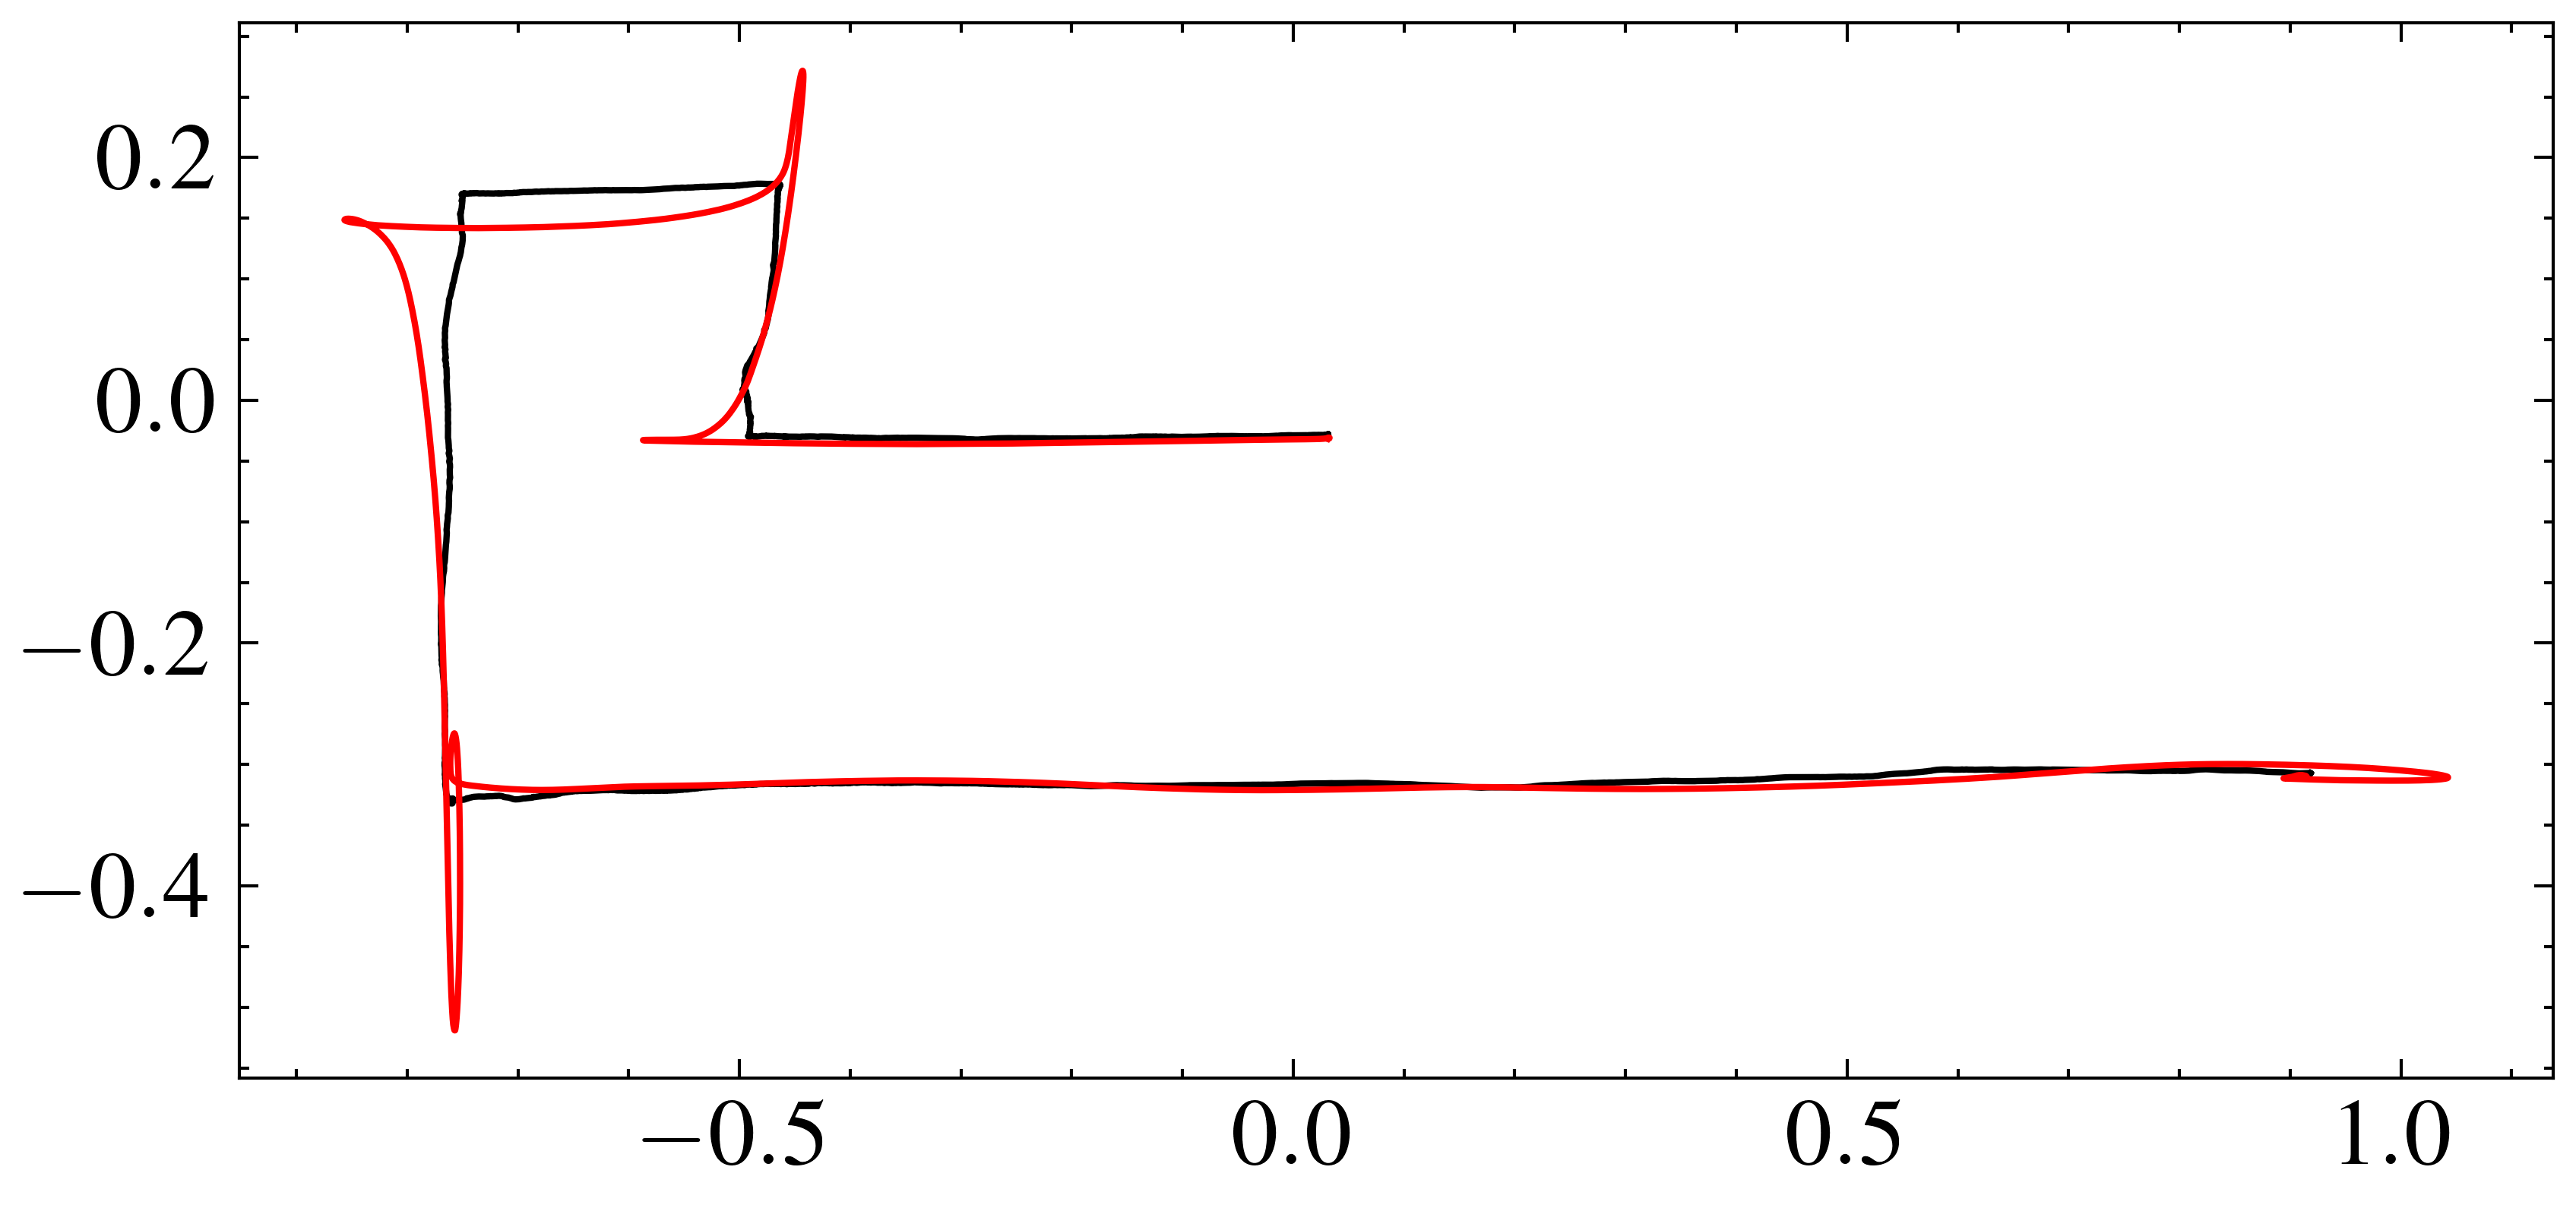

In [4]:
plt.figure(figsize=(6, 3))
plt.plot(pos2_vvo, pos1_vvo, '-')
plt.plot(pos2_vo, pos1_vo, '-')

plt.tight_layout()
plt.show()

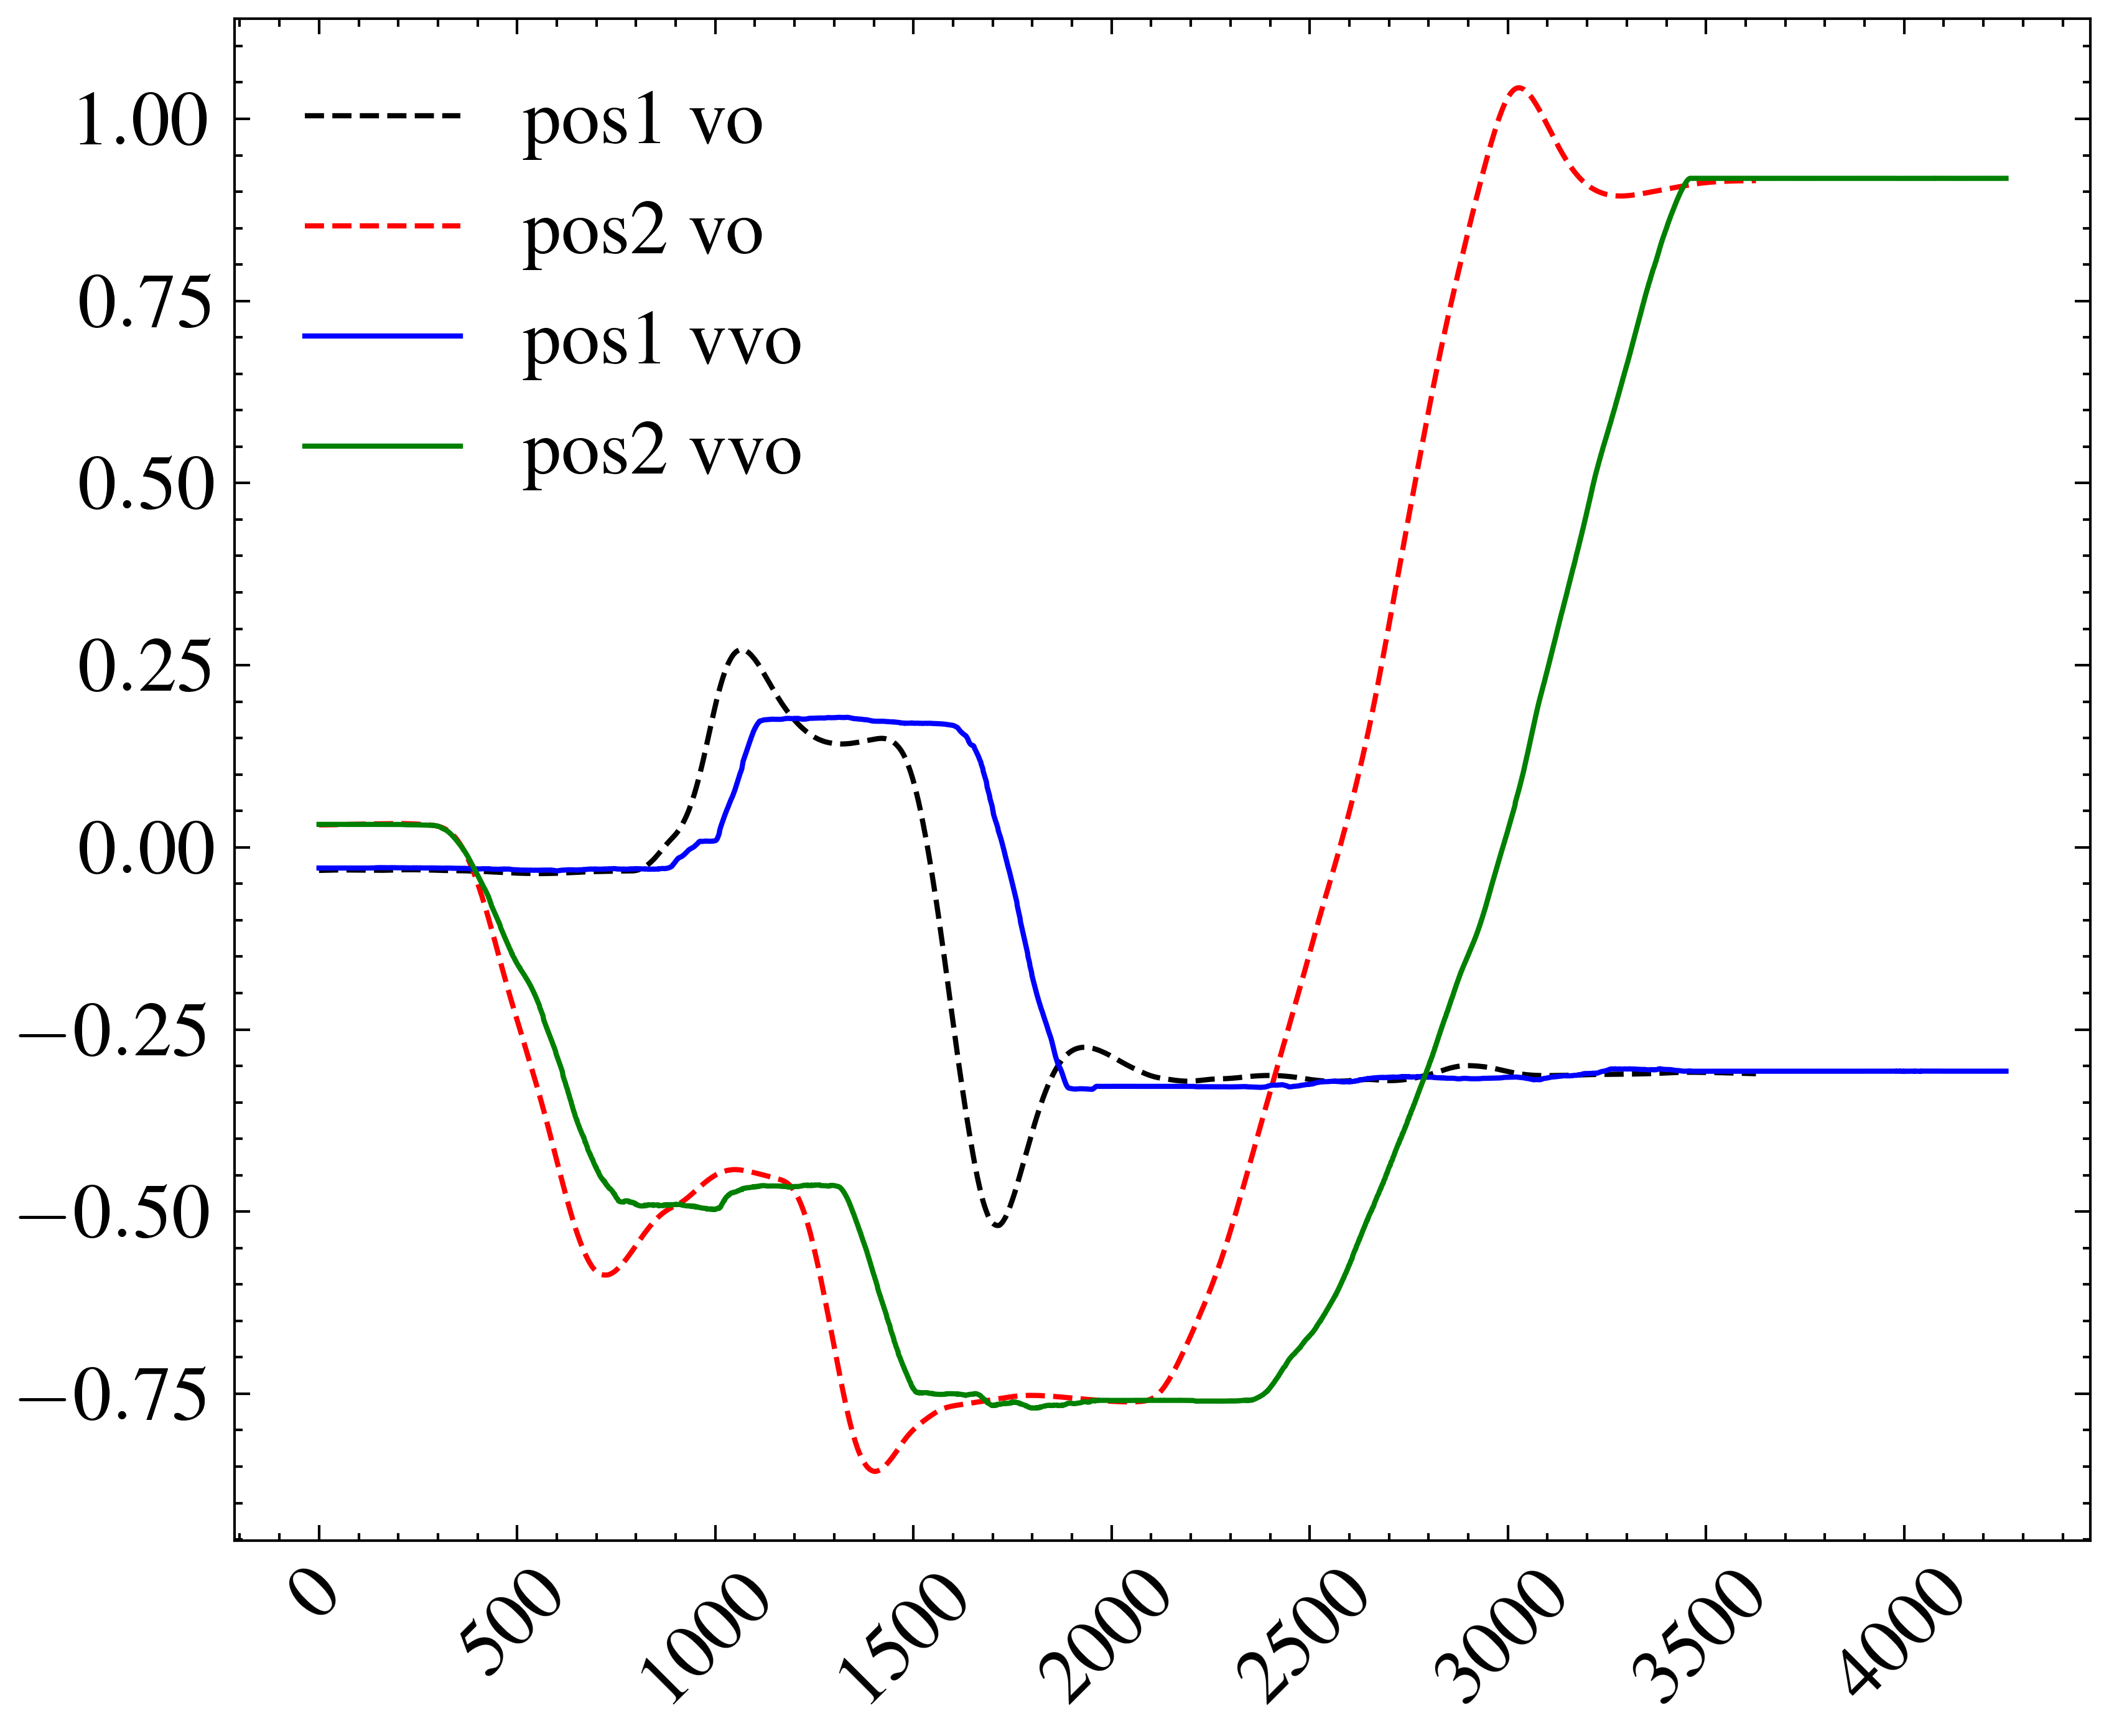

In [19]:
# ...existing code...
plt.figure(figsize=(6, 5))
ax = plt.gca()

# plot with time on x-axis (safer than implicit indices)
ax.plot(pos1_vo, '--', label='pos1 vo')
ax.plot(pos2_vo, '--', label='pos2 vo')
ax.plot(pos1_vvo, '-', label='pos1 vvo')
ax.plot(pos2_vvo, '-', label='pos2 vvo')

# OPTION A — set an explicit number of ticks using MaxNLocator
import matplotlib.ticker as mticker
ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=10))  # increase nbins as needed

# OPTION B — set tick positions manually (e.g. 9 ticks evenly spaced)
# xticks = np.linspace(min(t_vo.min(), t_vvo.min()), max(t_vo.max(), t_vvo.max()), 9)
# ax.set_xticks(xticks)
# ax.set_xticklabels([f"{x:.1f}" for x in xticks])

ax.tick_params(axis='x', rotation=45)   # rotate for readability
ax.legend()
plt.tight_layout()
plt.show()
# ...existing code...


In [17]:
print(pos1_vvo[0], pos2_vvo[0], t_vvo[0])
print(pos1_vvo[-1], pos2_vvo[-1], t_vvo[-1])

-0.028391311 0.03153263 0.0
-0.3072562 0.91835254 36.272924


In [20]:
# Find reference values
ref_t = np.array([0.032, 2.524, 4.107, 4.267, 4.574, 5.145, 5.582, 6.518, 8.707, 9.041, 11.433, 13.007, 14.390, 14.734, 20.469, 24.915, 29.448, 35.256, 7.690, 8.756, 9.616, 14.017, 14.406, 16.367, 27.773])

In [21]:
def align_to_reference_time(time_values, t_vvo, pos1_vvo, pos2_vvo):
    """
    Aligns pos1_vvo and pos2_vvo data to a new set of reference time_values.

    For each timestamp in time_values, it finds the closest timestamp in
    t_vvo and samples the corresponding data from pos1_vvo and pos2_vvo.

    Args:
        time_values (array-like): The new reference timestamps to align to.
        t_vvo (array-like): The original timestamps for the sensor data.
        pos1_vvo (array-like): The original position 1 data.
        pos2_vvo (array-like): The original position 2 data.

    Returns:
        tuple: A tuple containing:
            - target_times (np.ndarray): The sorted time_values array.
            - pos1_ref (np.ndarray): The new pos1 data aligned to target_times.
            - pos2_ref (np.ndarray): The new pos2 data aligned to target_times.
    """
    # Ensure all inputs are NumPy arrays for efficient processing
    t_vvo = np.asarray(t_vvo)
    pos1_vvo = np.asarray(pos1_vvo)
    pos2_vvo = np.asarray(pos2_vvo)
    time_values = np.asarray(time_values)

    # 1. Sort the target time_values array as requested
    target_times = np.sort(time_values)

    # 2. Find the closest matching time value in t_vvo for each target_time
    #    We use broadcasting to create a 2D matrix of all differences:
    #    Rows = target_times, Columns = t_vvo
    #    Shape: (len(target_times), len(t_vvo))
    diff_matrix = np.abs(target_times[:, np.newaxis] - t_vvo[np.newaxis, :])

    #    np.argmin(axis=1) finds the index (column) of the minimum value
    #    in each row. This gives us the index in t_vvo that is closest
    #    to each value in target_times.
    closest_indices = np.argmin(diff_matrix, axis=1)

    # 3. Store the values from pos1_vvo and pos2_vvo at those indices
    #    We use these indices to "sample" the original position arrays.
    pos1_ref = pos1_vvo[closest_indices]
    pos2_ref = pos2_vvo[closest_indices]

    return target_times, pos1_ref, pos2_ref

In [22]:
t_ref, pos1_ref, pos2_ref = align_to_reference_time(ref_t, t_vvo, pos1_vvo, pos2_vvo)

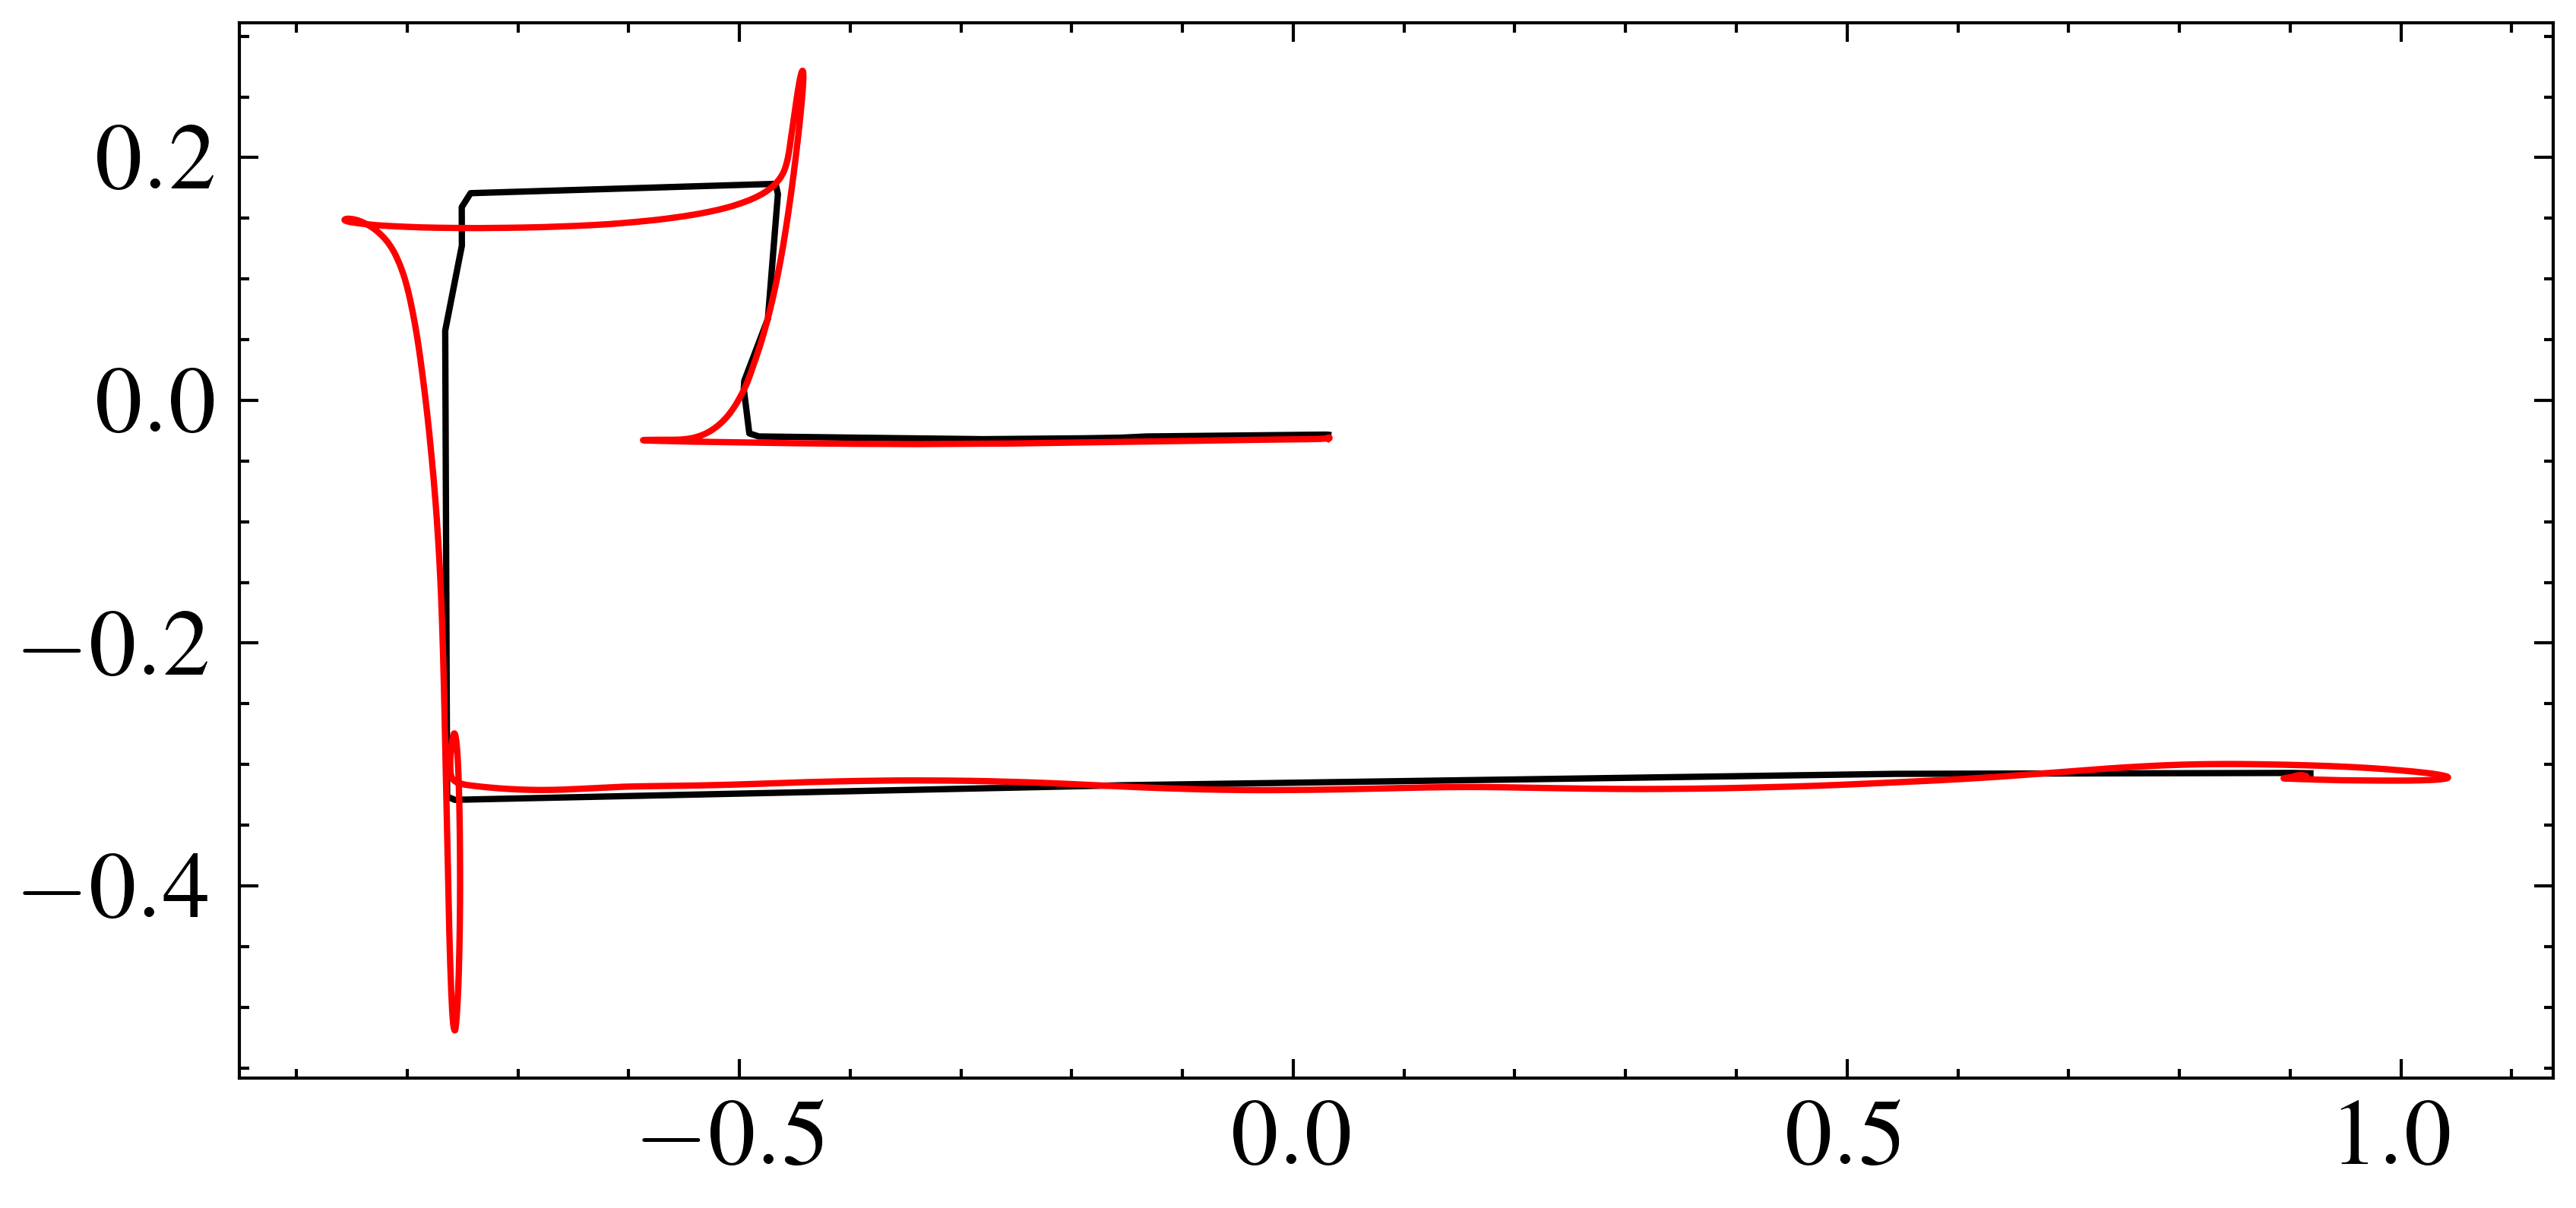

In [23]:
# Plot reference against EKF2 estimates
plt.figure(figsize=(6, 3))
plt.plot(pos2_ref, pos1_ref, '-')
plt.plot(pos2_vo, pos1_vo, '-')

plt.tight_layout()
plt.show()

In [84]:
# Interpolate reference position data to match EKF2 timestamps
pos1_ref_interp = np.interp(t_vo, t_ref, pos1_ref)
pos2_ref_interp = np.interp(t_vo, t_ref, pos2_ref)
# Calculate position errors
pos1_error = (pos1_vo - pos1_ref_interp)
pos2_error = (pos2_vo - pos2_ref_interp)
# Calculate percentage errors
pos1_percentage_error = (pos1_error / pos1_ref_interp) * 100
pos2_percentage_error = (pos2_error / pos2_ref_interp) * 100
# Calculate RMSE
pos1_rmse = np.sqrt(np.mean(pos1_error**2))
pos2_rmse = np.sqrt(np.mean(pos2_error**2))
print(f"Position 1 RMSE: {pos1_rmse:.4f} m")
print(f"Position 2 RMSE: {pos2_rmse:.4f} m")

Position 1 RMSE: 0.0419 m
Position 2 RMSE: 0.0558 m


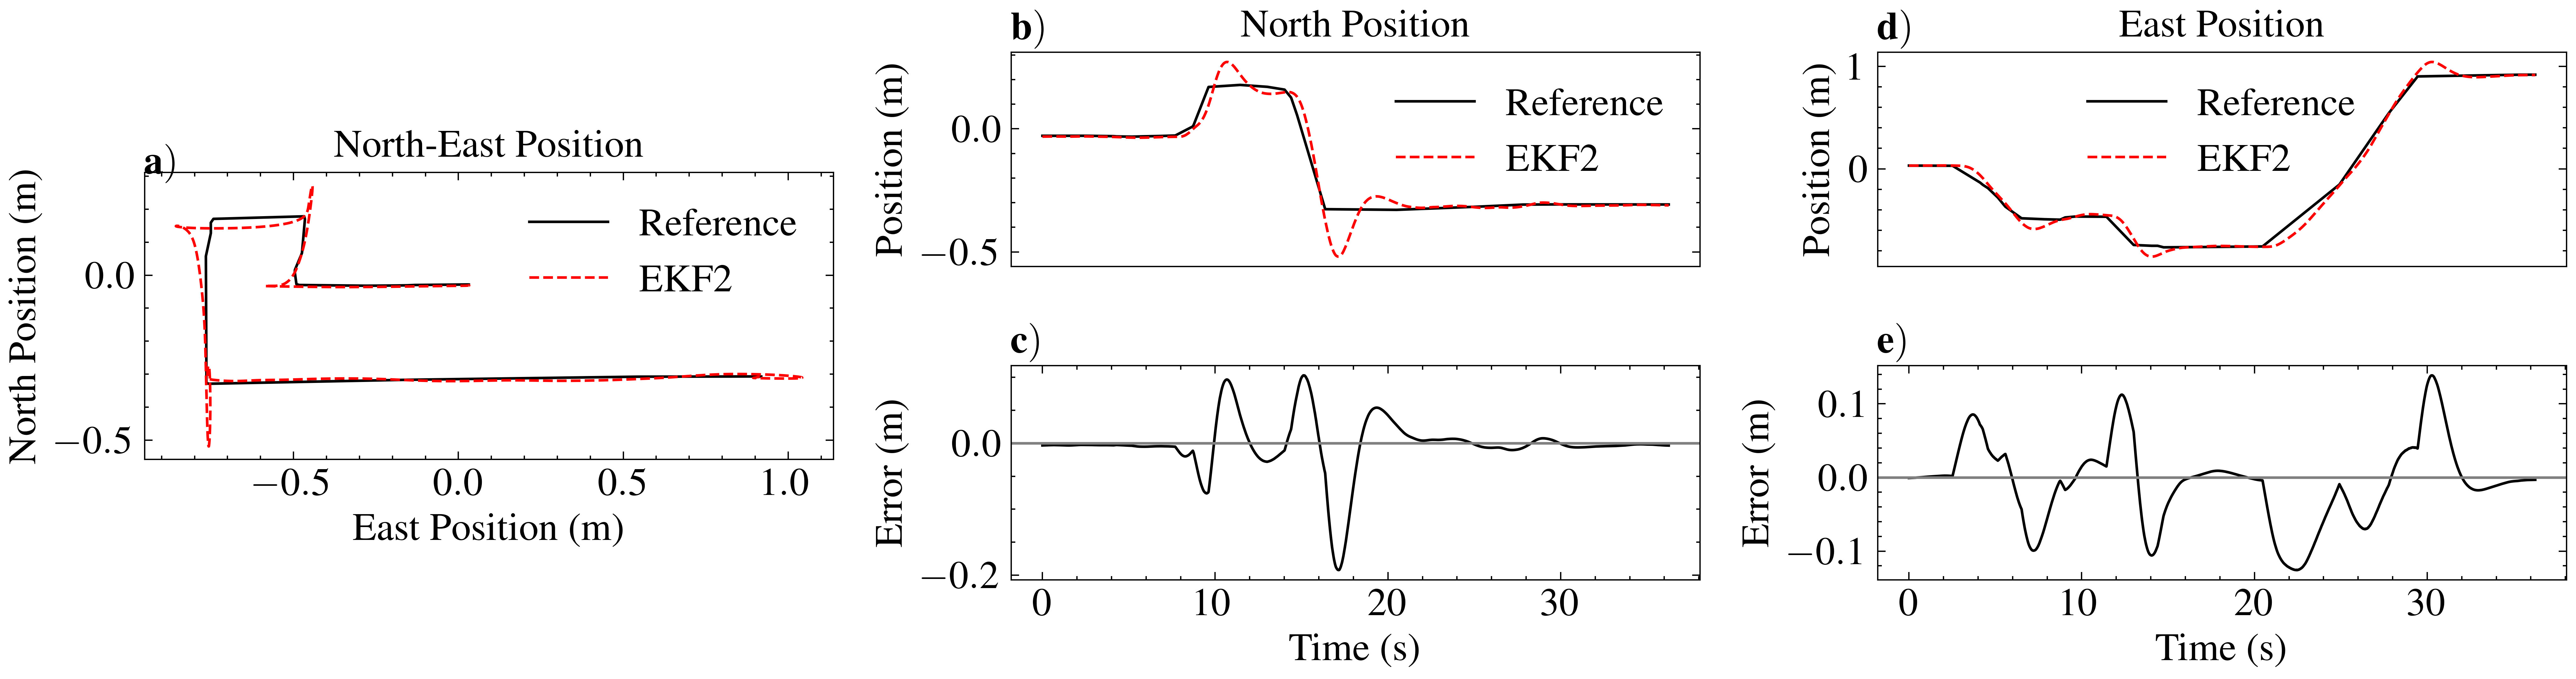

In [ ]:
# plt.figure(figsize=(6, 3))
# plt.subplot(2,1,1)
# plt.plot(t_ref, pos1_ref, '-')
# plt.plot(t_vo, pos1_vo, '--')

# 1. Define the layout as a list of lists.
#    'left' appears in both rows, so it spans the entire left column.
layout = [
    ['left', 'top_middle', 'top_right'],
    ['left', 'bottom_middle', 'bottom_right']
]

# 2. Create the figure and axes dictionary
fig, ax_dict = plt.subplot_mosaic(layout, figsize=(14, 4))

# 3. Plot on each axis using its key
# ax_dict['left'].set_aspect('equal') $ Show ground truth plot with equal scaling
ax_dict['left'].plot(pos2_ref, pos1_ref, '-', label='Reference')
ax_dict['left'].plot(pos2_vo, pos1_vo, '--', label='EKF2')
ax_dict['left'].set_title('North-East Position')
ax_dict['left'].set_xlabel('East Position (m)')
ax_dict['left'].set_ylabel('North Position (m)')
ax_dict['left'].text(0, 1.1, r'$\bf{a)}$', transform=ax_dict['left'].transAxes, ha='left', va='top')
ax_dict['left'].legend()

ax_dict['top_middle'].plot(t_vo, pos1_ref_interp, '-', label='Reference')
ax_dict['top_middle'].plot(t_vo, pos1_vo, '--', label='EKF2')
ax_dict['top_middle'].set_title('North Position')
ax_dict['top_middle'].xaxis.set_visible(False)
ax_dict['top_middle'].set_ylabel('Position (m)')
ax_dict['top_middle'].text(0, 1.2, r'$\bf{b)}$', transform=ax_dict['top_middle'].transAxes, ha='left', va='top')
ax_dict['top_middle'].legend()

ax_dict['top_right'].plot(t_vo, pos2_ref_interp, '-', label='Reference')
ax_dict['top_right'].plot(t_vo, pos2_vo, '--', label='EKF2')
ax_dict['top_right'].set_title('East Position')
ax_dict['top_right'].xaxis.set_visible(False)
ax_dict['top_right'].set_ylabel('Position (m)')
ax_dict['top_right'].text(0, 1.2, r'$\bf{d)}$', transform=ax_dict['top_right'].transAxes, ha='left', va='top')
ax_dict['top_right'].legend()

ax_dict['bottom_middle'].plot(t_vo, pos1_error, '-')
ax_dict['bottom_middle'].axhline(0, color='grey', linestyle='-', linewidth=1)
# ax_dict['bottom_middle'].set_title('North Position Error')
ax_dict['bottom_middle'].set_xlabel('Time (s)')
ax_dict['bottom_middle'].set_ylabel('Error (m)')
ax_dict['bottom_middle'].text(0, 1.2, r'$\bf{c)}$', transform=ax_dict['bottom_middle'].transAxes, ha='left', va='top')

ax_dict['bottom_right'].plot(t_vo, pos2_error, '-')
ax_dict['bottom_right'].axhline(0, color='grey', linestyle='-', linewidth=1)
# ax_dict['bottom_right'].set_title('East Position Error')
ax_dict['bottom_right'].set_xlabel('Time (s)')
ax_dict['bottom_right'].set_ylabel('Error (m)')
ax_dict['bottom_right'].text(0, 1.2, r'$\bf{e)}$', transform=ax_dict['bottom_right'].transAxes, ha='left', va='top')

# Adjust layout to prevent titles from overlapping
plt.tight_layout()
plt.savefig("ground_truth_1.pdf", bbox_inches='tight')
plt.show()

In [83]:
# Find index of maximum percentage error in pos1_percentage_error
print(np.argmax(pos1_percentage_error))
print(pos1_error[np.argmax(pos1_percentage_error)])
print(pos1_ref_interp[np.argmax(pos1_percentage_error)])

841
-0.018258503774835795
-7.641222516420465e-05
